In [1]:
!pip install shap
!pip install boruta

In [2]:
import pandas as pd
import numpy as np
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import xgboost as xgbimport
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from boruta import BorutaPy



# Load the data
df = pd.read_csv(
    'large_fires_data_v2_ndfb_kd_co.csv',
    names= [
        'point_id',
        'lat_dd',
        'long_dd',
        'ndfb_kd_co',
        'Aspect',
        'Climatic water deficit',
        'Elevation',
        'Humidity',
        'LULC',
        'NDVI',
        'Evaptranspiration',
        'Precipitation',
        'Slope',
        'Soil moisture',
        'Shortwave radiation flux',
        'Maximum Temperature',
        'Wind speed',
        'dist_fores',
        'human_foot',
        'tree_speci',
        'pdsi'
    ],
    header= 0
)

In [3]:
df.head()

,point_id,lat_dd,long_dd,ndfb_kd_co,Aspect,Climatic water deficit,Elevation,Humidity,LULC,NDVI,...,Precipitation,Slope,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,dist_fores,human_foot,tree_speci,pdsi
0,118462,60.383883,-100.961333,0.003040,108,25.791901,343.622009,0.003105,5,0.185952,...,33.974201,0,38.638302,122.428001,-2.81874,5.04358,0.00000,0,18,3.842920
1,188536,68.383883,-97.544667,0.000000,30,-9999.000000,29.983200,0.002183,8,0.079882,...,-9999.000000,0,-9999.000000,-9999.000000,-9999.00000,-9999.00000,306.02301,0,0,-9999.000000
2,142254,63.383883,-94.961333,0.000000,113,35.641201,142.042007,0.002544,3,0.118337,...,25.044300,0,39.882900,120.940002,-5.93237,5.63601,45.00000,0,0,-0.417361
3,170110,66.383883,-123.044667,0.000598,-1,25.696800,156.000000,0.003055,11,-0.051117,...,22.537500,0,18.849199,104.688003,-1.79748,3.65383,14.14210,-9999,0,-0.851500
4,5182,46.133883,-73.544667,0.000017,25,16.150000,94.138496,0.005531,2,0.429686,...,96.328300,0,49.552502,146.054001,10.93730,2.69233,0.00000,32,0,1.050420


In [4]:
# Replace -9999 with NaN
df.replace(-9999, np.nan, inplace=True)

# Verify if replacement was successful by checking for null values
df.isnull().sum()

,0
point_id,0
lat_dd,0
long_dd,0
ndfb_kd_co,0
Aspect,27
Climatic water deficit,78
Elevation,171
Humidity,98
LULC,103
NDVI,115


In [5]:
# Drop rows with NaN values
df.dropna(inplace=True)

In [6]:
replace_values_LULC = {
    1: 'Urban_areas',
    2: 'Crop_land',
    3: 'Grass_land',
    4: 'Tree_covered',
    5: 'Shrub_covered',
    6: 'Herbaceous',
    8: 'Sparse_vegetation',
    9: 'Bare_soil',
    10: 'Snow',
    11: 'Water_bodies',
}

df['LULC'] = df['LULC'].replace(replace_values_LULC)

In [7]:
df.head(10)

,point_id,lat_dd,long_dd,ndfb_kd_co,Aspect,Climatic water deficit,Elevation,Humidity,LULC,NDVI,...,Precipitation,Slope,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,dist_fores,human_foot,tree_speci,pdsi
0,118462,60.383883,-100.961333,0.003040,108.0,25.791901,343.622009,0.003105,Shrub_covered,0.185952,...,33.974201,0.0,38.638302,122.428001,-2.81874,5.04358,0.000000,0.0,18.0,3.842920
2,142254,63.383883,-94.961333,0.000000,113.0,35.641201,142.042007,0.002544,Grass_land,0.118337,...,25.044300,0.0,39.882900,120.940002,-5.93237,5.63601,45.000000,0.0,0.0,-0.417361
4,5182,46.133883,-73.544667,0.000017,25.0,16.150000,94.138496,0.005531,Crop_land,0.429686,...,96.328300,0.0,49.552502,146.054001,10.93730,2.69233,0.000000,32.0,0.0,1.050420
5,5180,46.133883,-73.711333,0.000000,62.0,14.517400,213.761993,0.005358,Tree_covered,0.509989,...,99.220001,1.0,53.683300,145.434998,10.80500,2.62192,0.000000,15.0,6.0,1.075170
6,23536,49.883883,-110.961333,0.000000,102.0,85.902199,766.164002,0.004427,Crop_land,0.306533,...,25.574200,0.0,8.550000,159.216995,12.03230,4.51617,49.497501,17.0,0.0,-0.115882
7,171330,66.467217,-88.378000,0.000000,74.0,34.307098,298.561005,0.002100,Sparse_vegetation,0.064672,...,25.674900,0.0,11.649000,112.188003,-8.41979,4.58282,386.942993,0.0,0.0,-0.419509
8,171040,66.467217,-112.628000,0.000000,205.0,37.411499,481.976990,0.002597,Grass_land,0.126665,...,20.446300,0.0,25.186300,105.348999,-5.18341,4.58974,63.245602,0.0,0.0,0.649869
9,133520,62.300550,-101.711333,0.002948,-1.0,16.660000,266.000000,0.002877,Water_bodies,0.000924,...,27.469000,0.0,38.008800,118.398003,-4.02748,5.48379,18.027800,0.0,0.0,0.135204
11,197830,69.717217,-95.294667,0.000000,236.0,28.190901,16.423500,0.002033,Sparse_vegetation,0.037350,...,13.080000,0.0,5.873330,104.623001,-9.58655,4.75425,411.096008,0.0,0.0,-2.166500
12,165028,65.800550,-88.628000,0.000000,217.0,36.887501,180.914002,0.002130,Sparse_vegetation,0.084306,...,26.125700,1.0,14.422900,114.267998,-7.52132,5.24746,345.398010,0.0,0.0,0.046837


In [8]:
# Convert necessary columns to categorical
df = df.astype(
    {
        'LULC': 'category'
    }
)

In [9]:
# # Replace -9999 with NaN
# df.replace(-9999, np.nan, inplace= True)

# # Fill NaN values using forward and Backward fill
# df.fillna(method='ffill', inplace= True)
# df.fillna(method= 'bfill', inplace= True)

In [10]:
df

,point_id,lat_dd,long_dd,ndfb_kd_co,Aspect,Climatic water deficit,Elevation,Humidity,LULC,NDVI,...,Precipitation,Slope,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,dist_fores,human_foot,tree_speci,pdsi
0,118462,60.383883,-100.961333,0.003040,108.0,25.791901,343.622009,0.003105,Shrub_covered,0.185952,...,33.974201,0.0,38.638302,122.428001,-2.818740,5.04358,0.000000,0.0,18.0,3.842920
2,142254,63.383883,-94.961333,0.000000,113.0,35.641201,142.042007,0.002544,Grass_land,0.118337,...,25.044300,0.0,39.882900,120.940002,-5.932370,5.63601,45.000000,0.0,0.0,-0.417361
4,5182,46.133883,-73.544667,0.000017,25.0,16.150000,94.138496,0.005531,Crop_land,0.429686,...,96.328300,0.0,49.552502,146.054001,10.937300,2.69233,0.000000,32.0,0.0,1.050420
5,5180,46.133883,-73.711333,0.000000,62.0,14.517400,213.761993,0.005358,Tree_covered,0.509989,...,99.220001,1.0,53.683300,145.434998,10.805000,2.62192,0.000000,15.0,6.0,1.075170
6,23536,49.883883,-110.961333,0.000000,102.0,85.902199,766.164002,0.004427,Crop_land,0.306533,...,25.574200,0.0,8.550000,159.216995,12.032300,4.51617,49.497501,17.0,0.0,-0.115882
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,42164,51.800550,-119.294667,0.066987,298.0,40.247398,1234.609985,0.004255,Tree_covered,0.364348,...,82.198196,17.0,38.228600,137.061996,10.527200,1.63274,0.000000,12.0,30.0,-0.320638
9996,83453,55.967217,-102.628000,0.094061,10.0,24.782600,390.493988,0.003904,Shrub_covered,0.360019,...,43.674999,0.0,36.657501,135.151993,4.036580,3.20392,0.000000,0.0,29.0,-0.532250
9997,142023,63.383883,-114.211333,0.066603,45.0,45.147499,304.996002,0.003006,Shrub_covered,0.226289,...,23.678700,0.0,20.494400,115.484001,-0.881827,3.87582,0.000000,0.0,10.0,-0.742617
9998,21169,49.633883,-121.544667,0.151077,21.0,36.743301,1519.750000,0.004994,Tree_covered,0.370431,...,89.547996,10.0,120.483002,135.684006,10.706200,2.26293,0.000000,0.0,0.0,-0.813372


In [11]:
# Define features and target, X and y
X = df.drop(columns= ['ndfb_kd_co'])
y = df['ndfb_kd_co']

# Split data into training, validation and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [12]:
# Combine features and target back for each dataset
train_data = pd.concat([X_train[['lat_dd', 'long_dd']], y_train], axis=1)
val_data = pd.concat([X_val[['lat_dd', 'long_dd']], y_val], axis=1)
test_data = pd.concat([X_test[['lat_dd', 'long_dd']], y_test], axis=1)

# Save to CSV files
train_data.to_csv('training_data.csv', index=False)
val_data.to_csv('validation_data.csv', index=False)
test_data.to_csv('testing_data.csv', index=False)

In [13]:
# Define the columns to separate out
index_columns = [

                 'point_id',
                 'lat_dd',
                 'long_dd',
                 'dist_fores',
                 'human_foot',
                 'tree_speci',
                 'pdsi'
]

# Separate index columns for train, validation, and test sets
train_indices = X_train[index_columns]
val_indices = X_val[index_columns]
test_indices = X_test[index_columns]

# Drop these columns from the features
X_train = X_train.drop(columns=index_columns)
X_val = X_val.drop(columns=index_columns)
X_test = X_test.drop(columns=index_columns)


In [14]:
df.columns

Index(['point_id', 'lat_dd', 'long_dd', 'ndfb_kd_co', 'Aspect',
       'Climatic water deficit', 'Elevation', 'Humidity', 'LULC', 'NDVI',
       'Evaptranspiration', 'Precipitation', 'Slope', 'Soil moisture',
       'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed',
       'dist_fores', 'human_foot', 'tree_speci', 'pdsi'],
      dtype='object')

In [15]:
# Define categorical and numerical columns
categorical_columns = ['LULC']
numerical_columns = ['Climatic water deficit', 'Elevation', 'Humidity','NDVI',
       'Evaptranspiration', 'Precipitation', 'Slope', 'Soil moisture',
       'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed',]

# Initialize the OneHotEncoder and StandardScaler
encoder = OneHotEncoder(sparse_output=False)
scaler = StandardScaler()

# Fit and transform encoders/scalers on training data
X_train_encoded = pd.DataFrame(encoder.fit_transform(X_train[categorical_columns]),
                               columns=encoder.get_feature_names_out(categorical_columns))
X_val_encoded = pd.DataFrame(encoder.transform(X_val[categorical_columns]),
                             columns=encoder.get_feature_names_out(categorical_columns))
X_test_encoded = pd.DataFrame(encoder.transform(X_test[categorical_columns]),
                              columns=encoder.get_feature_names_out(categorical_columns))

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train[numerical_columns]), columns=numerical_columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val[numerical_columns]), columns=numerical_columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test[numerical_columns]), columns=numerical_columns)

# Concatenate encoded categorical and scaled numerical features
X_train_final = pd.concat([X_train_scaled.reset_index(drop=True), X_train_encoded.reset_index(drop=True)], axis=1)
X_val_final = pd.concat([X_val_scaled.reset_index(drop=True), X_val_encoded.reset_index(drop=True)], axis=1)
X_test_final = pd.concat([X_test_scaled.reset_index(drop=True), X_test_encoded.reset_index(drop=True)], axis=1)

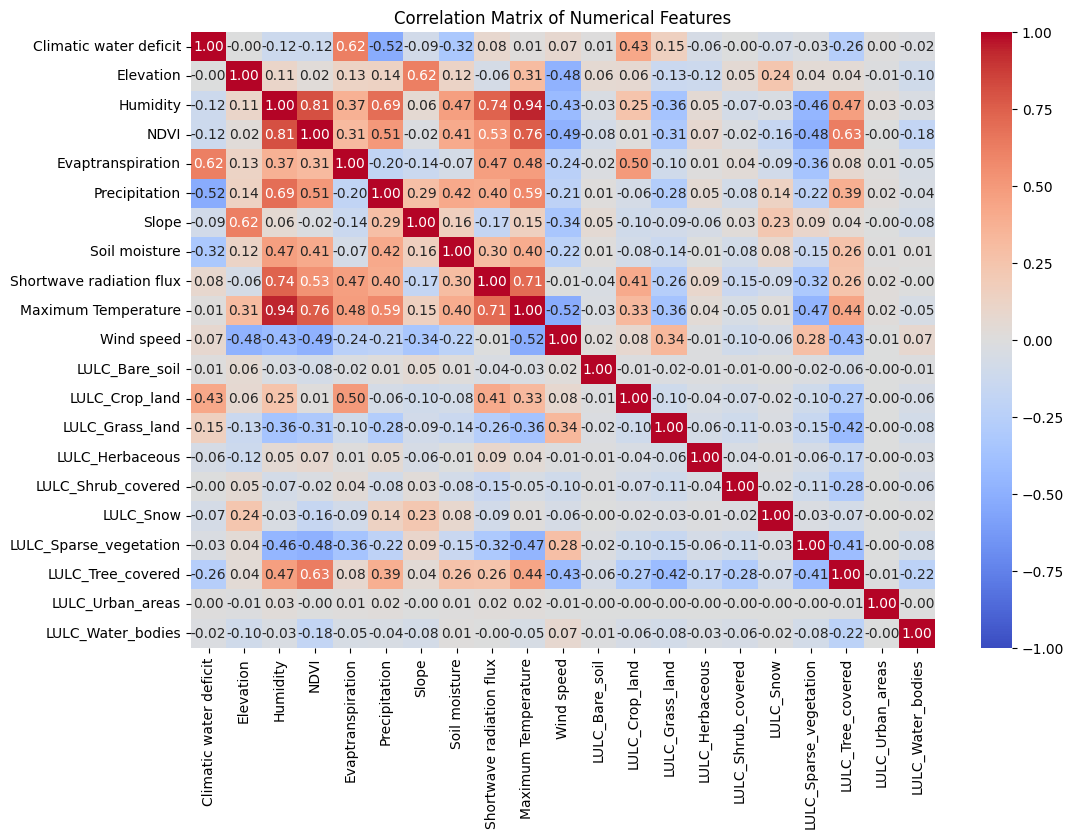

In [16]:
# Calculate correlation matrix for numerical features
correlation_matrix = X_train_final.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numerical Features")
plt.show()


In [17]:
# Initialize the RandomForestRegressor
rf = RandomForestRegressor(n_jobs=-1, max_depth=10, random_state=42)

# Fit the RandomForest model to get the feature importances
rf.fit(X_train_final, y_train)

# Initialize Boruta with the RandomForest model
boruta = BorutaPy(estimator=rf, n_estimators=20, max_iter=20, random_state=42, verbose=1)

# Fit Boruta on the preprocessed training data
boruta.fit(X_train_final.values, y_train.values)

# Create a DataFrame for the Boruta results
boruta_feature_stats = pd.DataFrame({
    'Variables': X_train_final.columns,
    'BorutaDecision': ['Confirmed' if decision else 'Rejected' for decision in boruta.support_]
})

# Initialize the DecisionTreeRegressor (CART)
cart_model = DecisionTreeRegressor(random_state=42)

# Fit the CART model to the training data
cart_model.fit(X_train_final, y_train)

# Extract feature importances
feature_importances = cart_model.feature_importances_

# Create a DataFrame for the CART results
cart_feature_stats = pd.DataFrame({
    'Variables': X_train_final.columns,
    'RelativeImportance': feature_importances
})

# Combine Boruta and CART results
combined_feature_stats = boruta_feature_stats.merge(cart_feature_stats, on='Variables')

# Save the combined feature stats (both confirmed and rejected) to a CSV file
combined_feature_stats.to_csv('final_feature_stats_with_rejected.csv', index=False)

# Features removed by Boruta
boruta_removed_features = combined_feature_stats[combined_feature_stats['BorutaDecision'] == 'Rejected']['Variables']

# Features with very low importance in CART (threshold < 0.0005)
cart_removed_features = combined_feature_stats[combined_feature_stats['RelativeImportance'] < 0.0005]['Variables']

# Combine the removed features from both methods
removed_features = pd.concat([boruta_removed_features, cart_removed_features]).unique()

# Print removed features
print("Features removed by Boruta or CART:", removed_features)

# Display the final feature stats for those that are kept
final_feature_stats = combined_feature_stats[~combined_feature_stats['Variables'].isin(removed_features)]
print(final_feature_stats)

# Save the final confirmed features to a CSV file for documentation
final_feature_stats.to_csv('final_confirmed_features.csv', index=False)

# Drop the removed features from the datasets automatically
X_train_selected = X_train_final.drop(columns=removed_features, errors='ignore')
X_val_selected = X_val_final.drop(columns=removed_features, errors='ignore')
X_test_selected = X_test_final.drop(columns=removed_features, errors='ignore')

# Save the selected features datasets for reference
X_train_selected.to_csv('X_train_selected.csv', index=False)
X_val_selected.to_csv('X_val_selected.csv', index=False)
X_test_selected.to_csv('X_test_selected.csv', index=False)

# Display summary
print(f"Final selected features saved to: 'X_train_selected.csv', 'X_val_selected.csv', and 'X_test_selected.csv'")
print("Full feature stats (with rejected) saved to 'final_feature_stats_with_rejected.csv'")


Iteration: 1 / 20
Iteration: 2 / 20
Iteration: 3 / 20
Iteration: 4 / 20
Iteration: 5 / 20
Iteration: 6 / 20
Iteration: 7 / 20
Iteration: 8 / 20


BorutaPy finished running.

Iteration: 	9 / 20
Confirmed: 	11
Tentative: 	0
Rejected: 	10
Features removed by Boruta or CART: ['Slope' 'LULC_Bare_soil' 'LULC_Grass_land' 'LULC_Herbaceous'
 'LULC_Shrub_covered' 'LULC_Snow' 'LULC_Sparse_vegetation'
 'LULC_Tree_covered' 'LULC_Urban_areas' 'LULC_Water_bodies']
                   Variables BorutaDecision  RelativeImportance
0     Climatic water deficit      Confirmed            0.125209
1                  Elevation      Confirmed            0.100461
2                   Humidity      Confirmed            0.050542
3                       NDVI      Confirmed            0.022444
4          Evaptranspiration      Confirmed            0.075391
5              Precipitation      Confirmed            0.071349
7              Soil moisture      Confirmed            0.043403
8   Shortwave radiation flux      

In [18]:
# # Load the CSV file
# file_path = "/content/final_feature_stats_with_rejected.csv"  # Update with your actual file path
# df1 = pd.read_csv(file_path)

# # Sort by 'RelativeImportance' in descending order
# df_sorted = df1.sort_values(by="RelativeImportance", ascending=False)  # Corrected 'ascending'

# # Save the sorted file
# df_sorted.to_csv("final_feature_stats_sorted.csv", index=False)

# # Display sorted DataFrame
# print(df_sorted)

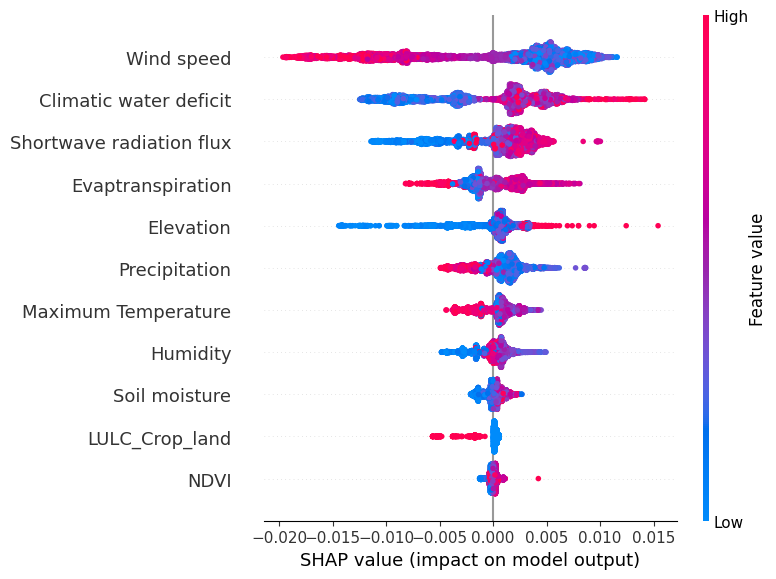

In [19]:
import shap
import xgboost as xgb
import matplotlib.pyplot as plt

# Convert datasets to XGBoost DMatrix for better performance (optional)
dtrain = xgb.DMatrix(X_train_selected, label=y_train)
dval = xgb.DMatrix(X_val_final, label=y_val)

# Train the XGBoost model
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.01, random_state=42)
xgb_model.fit(X_train_selected, y_train)

# Compute SHAP values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train_selected)

# SHAP summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train_selected, feature_names=X_train_selected.columns)


In [20]:
X_train_selected

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,-0.830688,-0.218214,1.324667,1.233257,0.604156,0.525807,1.011842,1.087708,0.968376,-0.510223,0.0
1,0.799524,-0.608056,-0.370016,-0.294047,1.017434,-0.709690,-1.102476,-0.675711,-0.280618,-0.916858,0.0
2,0.381872,0.110216,-1.291088,-1.113203,-0.357949,-0.914405,0.421268,-0.950878,-1.403284,1.456970,0.0
3,0.146703,-0.910844,0.775335,0.455542,0.283155,0.643507,0.171739,0.804901,0.605509,-0.733315,0.0
4,0.217869,-0.477207,-1.851333,-1.947729,-1.700576,-0.821806,-1.404596,-0.860161,-2.167361,0.929469,0.0
...,...,...,...,...,...,...,...,...,...,...,...
6752,-1.059826,2.613653,0.129962,-0.777020,-1.159355,2.265296,2.062632,-0.976687,0.556034,-0.915788,0.0
6753,-1.073705,0.206899,0.010595,-0.112351,-0.765094,0.719909,-0.368427,0.147929,-0.118446,0.267178,0.0
6754,0.772862,-0.631607,-0.328959,-0.189129,1.096721,-0.668200,-1.059448,-0.703959,-0.274567,-0.925872,0.0
6755,-0.718586,-0.904886,2.480092,2.108879,-0.616236,2.267797,2.644844,1.327307,1.711243,0.174134,0.0


In [21]:
X_test_selected

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,0.370637,-0.121730,-1.176259,-1.962385,-0.648101,-0.958061,0.392042,-1.023297,-1.360257,1.350602,0.0
1,3.781663,0.601709,0.849827,-0.330816,2.898495,-0.843171,-1.336715,2.155184,1.679785,0.727194,0.0
2,0.161464,0.090333,0.556241,0.759572,1.203045,-0.246458,0.730078,1.315495,0.815951,-0.203486,0.0
3,1.193754,-0.567825,-0.773498,0.070655,0.542157,-0.976770,-1.172152,-2.103163,-0.934863,-1.075020,0.0
4,0.290762,-0.214656,-0.157417,0.002949,0.458952,-0.252929,-0.443595,0.296875,-0.459257,0.113335,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1444,0.660906,0.549615,0.496612,-0.204269,1.537486,-0.323004,0.411520,1.452371,0.851480,0.235403,1.0
1445,-0.384778,-0.259187,0.143624,0.614816,0.388984,-0.183081,0.296269,0.581223,0.044320,-0.324427,0.0
1446,0.106856,-0.819538,-1.330237,-0.646587,-1.301638,-1.076092,-0.265338,-1.195806,-1.560841,1.549243,0.0
1447,-0.107265,-0.357590,0.291792,0.334854,0.693211,-0.150542,0.037170,0.629824,0.184958,-0.367892,0.0


In [22]:
X_val_selected

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,-0.126140,1.110494,-0.304912,0.582934,0.159703,-0.636256,-1.185961,-1.438936,0.079180,-1.353503,0.0
1,-0.339928,-0.165704,0.268766,0.636158,0.708478,-0.086076,0.055748,0.684524,0.196598,-0.497706,0.0
2,-0.290365,2.496674,-1.120891,-0.899553,0.503083,-0.510606,-0.958539,-1.620331,-0.427356,-0.776555,0.0
3,-0.228464,-0.724010,-0.852744,-1.057689,-0.141586,-0.431916,0.028194,0.116277,-0.939732,1.281662,0.0
4,-0.747607,-0.415219,-0.472096,-0.439870,-0.373321,-0.269574,-0.068611,0.364672,-0.595013,0.853177,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1443,1.369458,-0.421318,-0.887655,-0.572499,0.478163,-0.904590,-1.077298,-0.912935,-0.809977,-0.140969,0.0
1444,0.502190,0.050326,-1.150496,-0.499219,0.283525,-0.906981,0.090928,-0.997231,-1.206735,0.415546,0.0
1445,0.839211,-0.211422,-1.258890,-1.123027,0.041634,-0.984818,-1.087965,-1.498772,-1.266287,0.716809,0.0
1446,1.936956,-0.866141,-0.539925,-0.012756,1.189711,-0.801626,-0.925062,-1.436754,-0.486344,-1.413691,0.0


In [23]:
# Concatenate the index columns back with the selected features
X_train_final_with_indices = pd.concat([train_indices.reset_index(drop=True), X_train_selected.reset_index(drop=True)], axis=1)
X_val_final_with_indices = pd.concat([val_indices.reset_index(drop=True), X_val_selected.reset_index(drop=True)], axis=1)
X_test_final_with_indices = pd.concat([test_indices.reset_index(drop=True), X_test_selected.reset_index(drop=True)], axis=1)

# Save the updated datasets
X_train_final_with_indices.to_csv('X_train_final_with_indices.csv', index=False)
X_val_final_with_indices.to_csv('X_val_final_with_indices.csv', index=False)
X_test_final_with_indices.to_csv('X_test_final_with_indices.csv', index=False)


In [24]:
X_train_final_with_indices

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,20015,49.467217,-92.961333,0.000000,0.0,18.0,1.682080,-0.830688,-0.218214,1.324667,1.233257,0.604156,0.525807,1.011842,1.087708,0.968376,-0.510223,0.0
1,139903,63.133883,-119.294667,0.000000,0.0,0.0,-0.715007,0.799524,-0.608056,-0.370016,-0.294047,1.017434,-0.709690,-1.102476,-0.675711,-0.280618,-0.916858,0.0
2,161762,65.467217,-109.628000,72.111000,0.0,0.0,0.584173,0.381872,0.110216,-1.291088,-1.113203,-0.357949,-0.914405,0.421268,-0.950878,-1.403284,1.456970,0.0
3,35887,51.133883,-82.878000,0.000000,0.0,18.0,1.565920,0.146703,-0.910844,0.775335,0.455542,0.283155,0.643507,0.171739,0.804901,0.605509,-0.733315,0.0
4,174632,66.800550,-89.128000,436.834992,0.0,0.0,-0.672101,0.217869,-0.477207,-1.851333,-1.947729,-1.700576,-0.821806,-1.404596,-0.860161,-2.167361,0.929469,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6752,75708,55.133883,-128.378000,5.000000,0.0,0.0,-0.586667,-1.059826,2.613653,0.129962,-0.777020,-1.159355,2.265296,2.062632,-0.976687,0.556034,-0.915788,0.0
6753,58853,53.383883,-66.128000,0.000000,0.0,0.0,-1.131360,-1.073705,0.206899,0.010595,-0.112351,-0.765094,0.719909,-0.368427,0.147929,-0.118446,0.267178,0.0
6754,139231,63.050550,-119.628000,0.000000,0.0,0.0,-0.549935,0.772862,-0.631607,-0.328959,-0.189129,1.096721,-0.668200,-1.059448,-0.703959,-0.274567,-0.925872,0.0
6755,3663,45.550550,-64.294667,0.000000,8.0,0.0,0.371167,-0.718586,-0.904886,2.480092,2.108879,-0.616236,2.267797,2.644844,1.327307,1.711243,0.174134,0.0


In [25]:
X_val_final_with_indices

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,136443,62.717217,-133.211333,0.000000,0.0,18.0,1.957200,-0.126140,1.110494,-0.304912,0.582934,0.159703,-0.636256,-1.185961,-1.438936,0.079180,-1.353503,0.0
1,86252,56.300550,-104.044667,0.000000,0.0,18.0,-1.410000,-0.339928,-0.165704,0.268766,0.636158,0.708478,-0.086076,0.055748,0.684524,0.196598,-0.497706,0.0
2,154169,64.717217,-132.378000,5.000000,0.0,0.0,0.745807,-0.290365,2.496674,-1.120891,-0.899553,0.503083,-0.510606,-0.958539,-1.620331,-0.427356,-0.776555,0.0
3,113403,59.717217,-96.294667,0.000000,0.0,0.0,1.685580,-0.228464,-0.724010,-0.852744,-1.057689,-0.141586,-0.431916,0.028194,0.116277,-0.939732,1.281662,0.0
4,101251,58.133883,-97.711333,5.000000,0.0,0.0,0.666379,-0.747607,-0.415219,-0.472096,-0.439870,-0.373321,-0.269574,-0.068611,0.364672,-0.595013,0.853177,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1443,156859,64.967217,-115.961333,0.000000,0.0,0.0,-0.009367,1.369458,-0.421318,-0.887655,-0.572499,0.478163,-0.904590,-1.077298,-0.912935,-0.809977,-0.140969,0.0
1444,163194,65.633883,-114.878000,0.000000,0.0,17.0,-0.108571,0.502190,0.050326,-1.150496,-0.499219,0.283525,-0.906981,0.090928,-0.997231,-1.206735,0.415546,0.0
1445,182438,67.633883,-119.128000,60.827599,0.0,0.0,-0.645085,0.839211,-0.211422,-1.258890,-1.123027,0.041634,-0.984818,-1.087965,-1.498772,-1.266287,0.716809,0.0
1446,170006,66.383883,-131.711333,0.000000,0.0,0.0,0.518746,1.936956,-0.866141,-0.539925,-0.012756,1.189711,-0.801626,-0.925062,-1.436754,-0.486344,-1.413691,0.0


In [26]:
X_test_final_with_indices

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,164000,65.717217,-110.794667,80.622597,0.0,0.0,0.623167,0.370637,-0.121730,-1.176259,-1.962385,-0.648101,-0.958061,0.392042,-1.023297,-1.360257,1.350602,0.0
1,28077,50.383883,-111.628000,125.000000,13.0,0.0,-0.478534,3.781663,0.601709,0.849827,-0.330816,2.898495,-0.843171,-1.336715,2.155184,1.679785,0.727194,0.0
2,61804,53.717217,-106.628000,0.000000,0.0,18.0,1.254830,0.161464,0.090333,0.556241,0.759572,1.203045,-0.246458,0.730078,1.315495,0.815951,-0.203486,0.0
3,183745,67.800550,-139.961333,0.000000,1.0,0.0,-3.638680,1.193754,-0.567825,-0.773498,0.070655,0.542157,-0.976770,-1.172152,-2.103163,-0.934863,-1.075020,0.0
4,103834,58.467217,-102.628000,0.000000,4.0,18.0,-0.660333,0.290762,-0.214656,-0.157417,0.002949,0.458952,-0.252929,-0.443595,0.296875,-0.459257,0.113335,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1444,57531,53.300550,-107.878000,5.000000,15.0,0.0,1.257830,0.660906,0.549615,0.496612,-0.204269,1.537486,-0.323004,0.411520,1.452371,0.851480,0.235403,1.0
1445,89094,56.633883,-102.128000,0.000000,0.0,18.0,-0.693437,-0.384778,-0.259187,0.143624,0.614816,0.388984,-0.183081,0.296269,0.581223,0.044320,-0.324427,0.0
1446,173585,66.717217,-106.961333,18.027800,0.0,0.0,0.102763,0.106856,-0.819538,-1.330237,-0.646587,-1.301638,-1.076092,-0.265338,-1.195806,-1.560841,1.549243,0.0
1447,84162,56.050550,-102.211333,0.000000,0.0,0.0,-0.584083,-0.107265,-0.357590,0.291792,0.334854,0.693211,-0.150542,0.037170,0.629824,0.184958,-0.367892,0.0


In [27]:
X_train_final_with_indices

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,20015,49.467217,-92.961333,0.000000,0.0,18.0,1.682080,-0.830688,-0.218214,1.324667,1.233257,0.604156,0.525807,1.011842,1.087708,0.968376,-0.510223,0.0
1,139903,63.133883,-119.294667,0.000000,0.0,0.0,-0.715007,0.799524,-0.608056,-0.370016,-0.294047,1.017434,-0.709690,-1.102476,-0.675711,-0.280618,-0.916858,0.0
2,161762,65.467217,-109.628000,72.111000,0.0,0.0,0.584173,0.381872,0.110216,-1.291088,-1.113203,-0.357949,-0.914405,0.421268,-0.950878,-1.403284,1.456970,0.0
3,35887,51.133883,-82.878000,0.000000,0.0,18.0,1.565920,0.146703,-0.910844,0.775335,0.455542,0.283155,0.643507,0.171739,0.804901,0.605509,-0.733315,0.0
4,174632,66.800550,-89.128000,436.834992,0.0,0.0,-0.672101,0.217869,-0.477207,-1.851333,-1.947729,-1.700576,-0.821806,-1.404596,-0.860161,-2.167361,0.929469,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6752,75708,55.133883,-128.378000,5.000000,0.0,0.0,-0.586667,-1.059826,2.613653,0.129962,-0.777020,-1.159355,2.265296,2.062632,-0.976687,0.556034,-0.915788,0.0
6753,58853,53.383883,-66.128000,0.000000,0.0,0.0,-1.131360,-1.073705,0.206899,0.010595,-0.112351,-0.765094,0.719909,-0.368427,0.147929,-0.118446,0.267178,0.0
6754,139231,63.050550,-119.628000,0.000000,0.0,0.0,-0.549935,0.772862,-0.631607,-0.328959,-0.189129,1.096721,-0.668200,-1.059448,-0.703959,-0.274567,-0.925872,0.0
6755,3663,45.550550,-64.294667,0.000000,8.0,0.0,0.371167,-0.718586,-0.904886,2.480092,2.108879,-0.616236,2.267797,2.644844,1.327307,1.711243,0.174134,0.0


In [28]:
# Define the features to drop
features_to_drop = ['dist_fores', 'human_foot', 'pdsi', 'tree_speci']

# Load the datasets
train_file = "X_train_final_with_indices.csv"
val_file = "X_val_final_with_indices.csv"
test_file = "X_test_final_with_indices.csv"

X_train_final_with_indices = pd.read_csv(train_file)
X_val_final_with_indices = pd.read_csv(val_file)
X_test_final_with_indices = pd.read_csv(test_file)

# Drop the specified features
X_train_final_with_indices.drop(columns=features_to_drop, errors='ignore', inplace=True)
X_val_final_with_indices.drop(columns=features_to_drop, errors='ignore', inplace=True)
X_test_final_with_indices.drop(columns=features_to_drop, errors='ignore', inplace=True)

# Save the updated datasets
train_updated_file = "X_train_final_with_indices_updated.csv"
val_updated_file = "X_val_final_with_indices_updated.csv"
test_updated_file = "X_test_final_with_indices_updated.csv"

X_train_final_with_indices.to_csv(train_updated_file, index=False)
X_val_final_with_indices.to_csv(val_updated_file, index=False)
X_test_final_with_indices.to_csv(test_updated_file, index=False)



In [29]:
X_train_final_with_indices

,point_id,lat_dd,long_dd,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,20015,49.467217,-92.961333,-0.830688,-0.218214,1.324667,1.233257,0.604156,0.525807,1.011842,1.087708,0.968376,-0.510223,0.0
1,139903,63.133883,-119.294667,0.799524,-0.608056,-0.370016,-0.294047,1.017434,-0.709690,-1.102476,-0.675711,-0.280618,-0.916858,0.0
2,161762,65.467217,-109.628000,0.381872,0.110216,-1.291088,-1.113203,-0.357949,-0.914405,0.421268,-0.950878,-1.403284,1.456970,0.0
3,35887,51.133883,-82.878000,0.146703,-0.910844,0.775335,0.455542,0.283155,0.643507,0.171739,0.804901,0.605509,-0.733315,0.0
4,174632,66.800550,-89.128000,0.217869,-0.477207,-1.851333,-1.947729,-1.700576,-0.821806,-1.404596,-0.860161,-2.167361,0.929469,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6752,75708,55.133883,-128.378000,-1.059826,2.613653,0.129962,-0.777020,-1.159355,2.265296,2.062632,-0.976687,0.556034,-0.915788,0.0
6753,58853,53.383883,-66.128000,-1.073705,0.206899,0.010595,-0.112351,-0.765094,0.719909,-0.368427,0.147929,-0.118446,0.267178,0.0
6754,139231,63.050550,-119.628000,0.772862,-0.631607,-0.328959,-0.189129,1.096721,-0.668200,-1.059448,-0.703959,-0.274567,-0.925872,0.0
6755,3663,45.550550,-64.294667,-0.718586,-0.904886,2.480092,2.108879,-0.616236,2.267797,2.644844,1.327307,1.711243,0.174134,0.0


In [30]:
X_val_final_with_indices

,point_id,lat_dd,long_dd,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,136443,62.717217,-133.211333,-0.126140,1.110494,-0.304912,0.582934,0.159703,-0.636256,-1.185961,-1.438936,0.079180,-1.353503,0.0
1,86252,56.300550,-104.044667,-0.339928,-0.165704,0.268766,0.636158,0.708478,-0.086076,0.055748,0.684524,0.196598,-0.497706,0.0
2,154169,64.717217,-132.378000,-0.290365,2.496674,-1.120891,-0.899553,0.503083,-0.510606,-0.958539,-1.620331,-0.427356,-0.776555,0.0
3,113403,59.717217,-96.294667,-0.228464,-0.724010,-0.852744,-1.057689,-0.141586,-0.431916,0.028194,0.116277,-0.939732,1.281662,0.0
4,101251,58.133883,-97.711333,-0.747607,-0.415219,-0.472096,-0.439870,-0.373321,-0.269574,-0.068611,0.364672,-0.595013,0.853177,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1443,156859,64.967217,-115.961333,1.369458,-0.421318,-0.887655,-0.572499,0.478163,-0.904590,-1.077298,-0.912935,-0.809977,-0.140969,0.0
1444,163194,65.633883,-114.878000,0.502190,0.050326,-1.150496,-0.499219,0.283525,-0.906981,0.090928,-0.997231,-1.206735,0.415546,0.0
1445,182438,67.633883,-119.128000,0.839211,-0.211422,-1.258890,-1.123027,0.041634,-0.984818,-1.087965,-1.498772,-1.266287,0.716809,0.0
1446,170006,66.383883,-131.711333,1.936956,-0.866141,-0.539925,-0.012756,1.189711,-0.801626,-0.925062,-1.436754,-0.486344,-1.413691,0.0


In [31]:
X_test_final_with_indices

,point_id,lat_dd,long_dd,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,164000,65.717217,-110.794667,0.370637,-0.121730,-1.176259,-1.962385,-0.648101,-0.958061,0.392042,-1.023297,-1.360257,1.350602,0.0
1,28077,50.383883,-111.628000,3.781663,0.601709,0.849827,-0.330816,2.898495,-0.843171,-1.336715,2.155184,1.679785,0.727194,0.0
2,61804,53.717217,-106.628000,0.161464,0.090333,0.556241,0.759572,1.203045,-0.246458,0.730078,1.315495,0.815951,-0.203486,0.0
3,183745,67.800550,-139.961333,1.193754,-0.567825,-0.773498,0.070655,0.542157,-0.976770,-1.172152,-2.103163,-0.934863,-1.075020,0.0
4,103834,58.467217,-102.628000,0.290762,-0.214656,-0.157417,0.002949,0.458952,-0.252929,-0.443595,0.296875,-0.459257,0.113335,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1444,57531,53.300550,-107.878000,0.660906,0.549615,0.496612,-0.204269,1.537486,-0.323004,0.411520,1.452371,0.851480,0.235403,1.0
1445,89094,56.633883,-102.128000,-0.384778,-0.259187,0.143624,0.614816,0.388984,-0.183081,0.296269,0.581223,0.044320,-0.324427,0.0
1446,173585,66.717217,-106.961333,0.106856,-0.819538,-1.330237,-0.646587,-1.301638,-1.076092,-0.265338,-1.195806,-1.560841,1.549243,0.0
1447,84162,56.050550,-102.211333,-0.107265,-0.357590,0.291792,0.334854,0.693211,-0.150542,0.037170,0.629824,0.184958,-0.367892,0.0


## K-fold spatial cross validation

In [32]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# Load dataset
train_file_path = "X_train_final_with_indices.csv"  # Update with your file path
X_train_final_with_indices = pd.read_csv(train_file_path)

# Extract latitude and longitude
coordinates = X_train_final_with_indices[['lat_dd', 'long_dd']]

# Apply K-Means clustering to assign 10 spatial regions
n_splits = 10
kmeans = KMeans(n_clusters=n_splits, random_state=42, n_init=10)
X_train_final_with_indices['spatial_fold'] = kmeans.fit_predict(coordinates)

# Save the corrected spatial folds dataset
X_train_final_with_indices.to_csv("X_train_final_with_corrected_spatial_folds.csv", index=False)

# Display unique fold values
print("Unique spatial folds assigned:", X_train_final_with_indices['spatial_fold'].unique())
print("Spatial folds have been reassigned and saved to 'X_train_final_with_corrected_spatial_folds.csv'.")


Unique spatial folds assigned: [1 8 2 7 6 3 9 5 4 0]
Spatial folds have been reassigned and saved to 'X_train_final_with_corrected_spatial_folds.csv'.


In [33]:
tmp = pd.read_csv('X_train_final_with_corrected_spatial_folds.csv')
tmp

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land,spatial_fold
0,20015,49.467217,-92.961333,0.000000,0.0,18.0,1.682080,-0.830688,-0.218214,1.324667,1.233257,0.604156,0.525807,1.011842,1.087708,0.968376,-0.510223,0.0,1
1,139903,63.133883,-119.294667,0.000000,0.0,0.0,-0.715007,0.799524,-0.608056,-0.370016,-0.294047,1.017434,-0.709690,-1.102476,-0.675711,-0.280618,-0.916858,0.0,8
2,161762,65.467217,-109.628000,72.111000,0.0,0.0,0.584173,0.381872,0.110216,-1.291088,-1.113203,-0.357949,-0.914405,0.421268,-0.950878,-1.403284,1.456970,0.0,2
3,35887,51.133883,-82.878000,0.000000,0.0,18.0,1.565920,0.146703,-0.910844,0.775335,0.455542,0.283155,0.643507,0.171739,0.804901,0.605509,-0.733315,0.0,1
4,174632,66.800550,-89.128000,436.834992,0.0,0.0,-0.672101,0.217869,-0.477207,-1.851333,-1.947729,-1.700576,-0.821806,-1.404596,-0.860161,-2.167361,0.929469,0.0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6752,75708,55.133883,-128.378000,5.000000,0.0,0.0,-0.586667,-1.059826,2.613653,0.129962,-0.777020,-1.159355,2.265296,2.062632,-0.976687,0.556034,-0.915788,0.0,4
6753,58853,53.383883,-66.128000,0.000000,0.0,0.0,-1.131360,-1.073705,0.206899,0.010595,-0.112351,-0.765094,0.719909,-0.368427,0.147929,-0.118446,0.267178,0.0,3
6754,139231,63.050550,-119.628000,0.000000,0.0,0.0,-0.549935,0.772862,-0.631607,-0.328959,-0.189129,1.096721,-0.668200,-1.059448,-0.703959,-0.274567,-0.925872,0.0,8
6755,3663,45.550550,-64.294667,0.000000,8.0,0.0,0.371167,-0.718586,-0.904886,2.480092,2.108879,-0.616236,2.267797,2.644844,1.327307,1.711243,0.174134,0.0,3


In [34]:
tmp['spatial_fold'].value_counts(normalize=True)

,proportion
spatial_fold,
6,0.125943
9,0.114992
0,0.111588
5,0.107000
8,0.099600
2,0.098712
1,0.092201
3,0.090573
4,0.088353


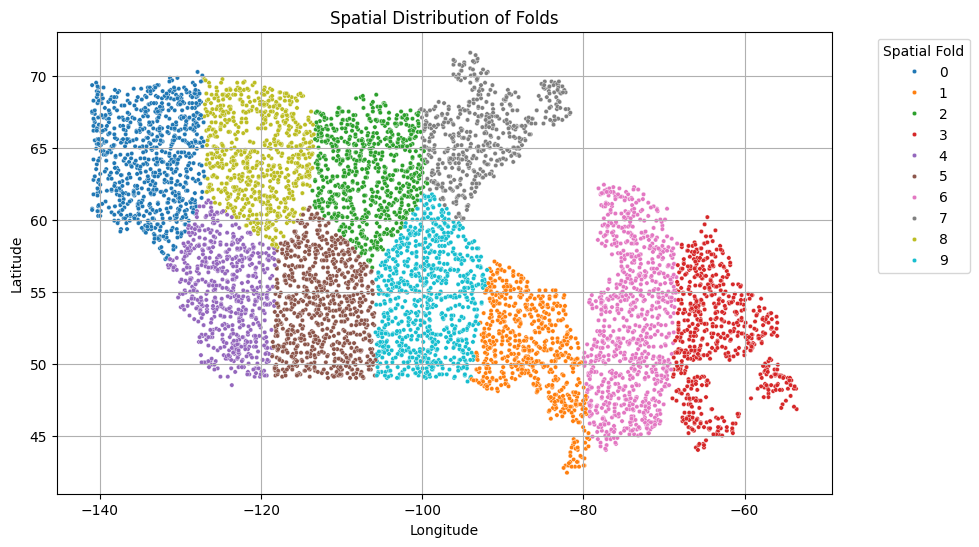

In [35]:
# Scatter plot of spatial folds
plt.figure(figsize=(10, 6))
sns.scatterplot(x=tmp["long_dd"], y=tmp["lat_dd"], hue=tmp["spatial_fold"], palette="tab10", s=10)
plt.title("Spatial Distribution of Folds")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Spatial Fold", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

In [36]:
X_train_final_with_indices.columns

Index(['point_id', 'lat_dd', 'long_dd', 'dist_fores', 'human_foot',
       'tree_speci', 'pdsi', 'Climatic water deficit', 'Elevation', 'Humidity',
       'NDVI', 'Evaptranspiration', 'Precipitation', 'Soil moisture',
       'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed',
       'LULC_Crop_land', 'spatial_fold'],
      dtype='object')

In [37]:
X_test_final_with_indices.columns

Index(['point_id', 'lat_dd', 'long_dd', 'Climatic water deficit', 'Elevation',
       'Humidity', 'NDVI', 'Evaptranspiration', 'Precipitation',
       'Soil moisture', 'Shortwave radiation flux', 'Maximum Temperature',
       'Wind speed', 'LULC_Crop_land'],
      dtype='object')

In [38]:
X_val_final_with_indices.columns

Index(['point_id', 'lat_dd', 'long_dd', 'Climatic water deficit', 'Elevation',
       'Humidity', 'NDVI', 'Evaptranspiration', 'Precipitation',
       'Soil moisture', 'Shortwave radiation flux', 'Maximum Temperature',
       'Wind speed', 'LULC_Crop_land'],
      dtype='object')

In [39]:
# Define features to drop
drop_features = ["point_id", "lat_dd", "long_dd", "dist_fores", "human_foot", "tree_speci", "pdsi"]

# Load the datasets
train_file = "X_train_final_with_corrected_spatial_folds.csv"
val_file = "X_val_final_with_indices.csv"
test_file = "X_test_final_with_indices.csv"

X_train_final_with_indices = pd.read_csv(train_file)
X_val_final_with_indices = pd.read_csv(val_file)
X_test_final_with_indices = pd.read_csv(test_file)

# Drop the specified features from training, validation, and test datasets
X_train_final_with_indices.drop(columns=drop_features, errors='ignore', inplace=True)
X_val_final_with_indices.drop(columns=drop_features, errors='ignore', inplace=True)
X_test_final_with_indices.drop(columns=drop_features, errors='ignore', inplace=True)

# Save the cleaned datasets
X_train_final_with_indices.to_csv("X_train_final_cleaned.csv", index=False)
X_val_final_with_indices.to_csv("X_val_final_cleaned.csv", index=False)
X_test_final_with_indices.to_csv("X_test_final_cleaned.csv", index=False)



In [40]:
X_train_final_with_indices

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land,spatial_fold
0,-0.830688,-0.218214,1.324667,1.233257,0.604156,0.525807,1.011842,1.087708,0.968376,-0.510223,0.0,1
1,0.799524,-0.608056,-0.370016,-0.294047,1.017434,-0.709690,-1.102476,-0.675711,-0.280618,-0.916858,0.0,8
2,0.381872,0.110216,-1.291088,-1.113203,-0.357949,-0.914405,0.421268,-0.950878,-1.403284,1.456970,0.0,2
3,0.146703,-0.910844,0.775335,0.455542,0.283155,0.643507,0.171739,0.804901,0.605509,-0.733315,0.0,1
4,0.217869,-0.477207,-1.851333,-1.947729,-1.700576,-0.821806,-1.404596,-0.860161,-2.167361,0.929469,0.0,7
...,...,...,...,...,...,...,...,...,...,...,...,...
6752,-1.059826,2.613653,0.129962,-0.777020,-1.159355,2.265296,2.062632,-0.976687,0.556034,-0.915788,0.0,4
6753,-1.073705,0.206899,0.010595,-0.112351,-0.765094,0.719909,-0.368427,0.147929,-0.118446,0.267178,0.0,3
6754,0.772862,-0.631607,-0.328959,-0.189129,1.096721,-0.668200,-1.059448,-0.703959,-0.274567,-0.925872,0.0,8
6755,-0.718586,-0.904886,2.480092,2.108879,-0.616236,2.267797,2.644844,1.327307,1.711243,0.174134,0.0,3


In [41]:
X_val_final_with_indices

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,-0.126140,1.110494,-0.304912,0.582934,0.159703,-0.636256,-1.185961,-1.438936,0.079180,-1.353503,0.0
1,-0.339928,-0.165704,0.268766,0.636158,0.708478,-0.086076,0.055748,0.684524,0.196598,-0.497706,0.0
2,-0.290365,2.496674,-1.120891,-0.899553,0.503083,-0.510606,-0.958539,-1.620331,-0.427356,-0.776555,0.0
3,-0.228464,-0.724010,-0.852744,-1.057689,-0.141586,-0.431916,0.028194,0.116277,-0.939732,1.281662,0.0
4,-0.747607,-0.415219,-0.472096,-0.439870,-0.373321,-0.269574,-0.068611,0.364672,-0.595013,0.853177,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1443,1.369458,-0.421318,-0.887655,-0.572499,0.478163,-0.904590,-1.077298,-0.912935,-0.809977,-0.140969,0.0
1444,0.502190,0.050326,-1.150496,-0.499219,0.283525,-0.906981,0.090928,-0.997231,-1.206735,0.415546,0.0
1445,0.839211,-0.211422,-1.258890,-1.123027,0.041634,-0.984818,-1.087965,-1.498772,-1.266287,0.716809,0.0
1446,1.936956,-0.866141,-0.539925,-0.012756,1.189711,-0.801626,-0.925062,-1.436754,-0.486344,-1.413691,0.0


In [42]:
X_test_final_with_indices

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,0.370637,-0.121730,-1.176259,-1.962385,-0.648101,-0.958061,0.392042,-1.023297,-1.360257,1.350602,0.0
1,3.781663,0.601709,0.849827,-0.330816,2.898495,-0.843171,-1.336715,2.155184,1.679785,0.727194,0.0
2,0.161464,0.090333,0.556241,0.759572,1.203045,-0.246458,0.730078,1.315495,0.815951,-0.203486,0.0
3,1.193754,-0.567825,-0.773498,0.070655,0.542157,-0.976770,-1.172152,-2.103163,-0.934863,-1.075020,0.0
4,0.290762,-0.214656,-0.157417,0.002949,0.458952,-0.252929,-0.443595,0.296875,-0.459257,0.113335,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1444,0.660906,0.549615,0.496612,-0.204269,1.537486,-0.323004,0.411520,1.452371,0.851480,0.235403,1.0
1445,-0.384778,-0.259187,0.143624,0.614816,0.388984,-0.183081,0.296269,0.581223,0.044320,-0.324427,0.0
1446,0.106856,-0.819538,-1.330237,-0.646587,-1.301638,-1.076092,-0.265338,-1.195806,-1.560841,1.549243,0.0
1447,-0.107265,-0.357590,0.291792,0.334854,0.693211,-0.150542,0.037170,0.629824,0.184958,-0.367892,0.0


In [43]:
X_train_final_with_indices.shape

(6757, 12)

In [44]:
y_train.shape

(6757,)

## 10-fold spatial cross-validation splitting

In [45]:
# Ensure indices are aligned
X_train_final_with_indices = X_train_final_with_indices.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

# Extract unique spatial folds
unique_folds = sorted(X_train_final_with_indices["spatial_fold"].unique())

# Prepare to store spatial fold splits
spatial_cv_splits = []

# Perform 10-Fold Spatial Cross-Validation Splitting
for fold in unique_folds:
    print(f"🔹 Preparing Fold {fold}...")

    # Define train and validation sets based on spatial fold
    train_data = X_train_final_with_indices[X_train_final_with_indices["spatial_fold"] != fold]
    val_data = X_train_final_with_indices[X_train_final_with_indices["spatial_fold"] == fold]

    # Extract train and validation indices
    train_indices = train_data.index
    val_indices = val_data.index

    # Drop "spatial_fold" from feature sets
    X_train_fold = train_data.drop(columns=["spatial_fold"])
    X_val_fold = val_data.drop(columns=["spatial_fold"])

    # Extract corresponding target values
    y_train_fold = y_train.iloc[train_indices]
    y_val_fold = y_train.iloc[val_indices]

    # Store the train-validation split for this fold
    spatial_cv_splits.append({
        "fold": fold,
        "X_train": X_train_fold,
        "y_train": y_train_fold,
        "X_val": X_val_fold,
        "y_val": y_val_fold
    })

print(f"\n✅ 10-Fold Spatial Cross-Validation Splits Prepared ({len(spatial_cv_splits)} Folds)")


🔹 Preparing Fold 0...
🔹 Preparing Fold 1...
🔹 Preparing Fold 2...
🔹 Preparing Fold 3...
🔹 Preparing Fold 4...
🔹 Preparing Fold 5...
🔹 Preparing Fold 6...
🔹 Preparing Fold 7...
🔹 Preparing Fold 8...
🔹 Preparing Fold 9...

✅ 10-Fold Spatial Cross-Validation Splits Prepared (10 Folds)


In [46]:
X_train.shape

(6757, 13)

In [47]:
y_train.shape

(6757,)

In [48]:
X_train_fold.shape

(5980, 11)

In [49]:
y_train_fold.shape

(5980,)

In [50]:
 X_val_fold.shape

(777, 11)

### Approach

1. Spatial K-fold cross-validation is for model selection, NOT Final training

* In spatial K-fold CV, we train on 9 folds and validate on 1 fold.
* each model in spatial CV is trained on only 90% of the trainig data, which means it does not fully utilize all available training data.
2. Final Model should be trained on FULL training data.
* Once we determine the best model, we should train it on 100% of the training data
* This ensures the model learns all available patterns.

# Deep Neural Network

### Train DNN model using 10-fold CV

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



🚀 Training Final Model on Full Training Data...
Epoch 1/70
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0067 - mae: 0.0534 - val_loss: 8.8015e-04 - val_mae: 0.0220
Epoch 2/70
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0011 - mae: 0.0238 - val_loss: 7.6949e-04 - val_mae: 0.0202
Epoch 3/70
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.0062e-04 - mae: 0.0210 - val_loss: 6.4253e-04 - val_mae: 0.0180
Epoch 4/70
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.0014e-04 - mae: 0.0197 - val_loss: 5.7081e-04 - val_mae: 0.0168
Epoch 5/70
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.2605e-04 - mae: 0.0188 - val_loss: 5.0118e-04 - val_mae: 0.0149
Epoch 6/70
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.8182e-04 - mae: 0.0174 - val_loss: 4.5499e-04 - val_mae: 0.0142
Epoch 7/70
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.2416e-04 - mae: 0.0168 - val_loss: 4.5777e-04 - val_mae: 0.0151
Epoch 8/70
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.7165e-04 - mae:


🎯 Final Model Performance on Test Data:
Test MSE: 0.000269
Test MAE: 0.011237
Test R² Score: 0.7522

✅ Final model saved successfully!


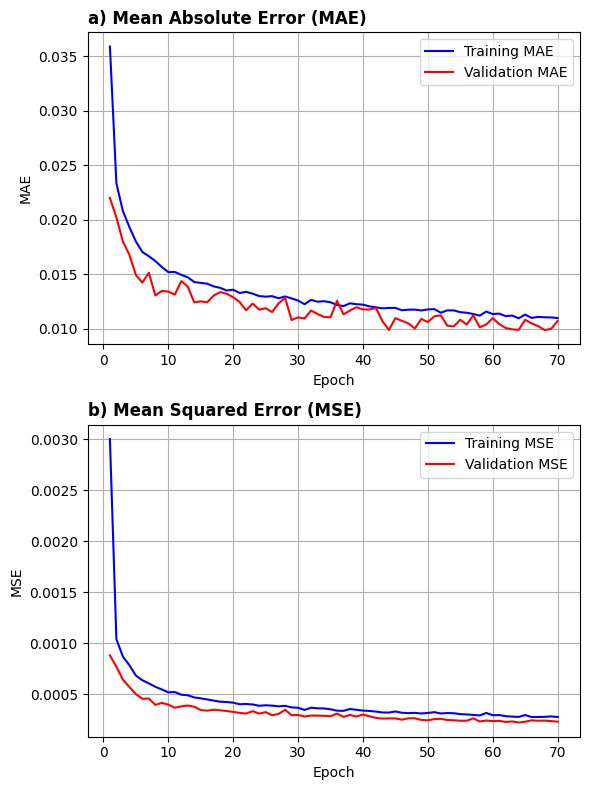

In [51]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# ✅ Best Hyperparameters (from tuning)
best_hyperparams = {
    "hidden_layers": 4,
    "neurons": 128,
    "dropout_rate": 0.2,
    "learning_rate": 0.001,
    "batch_size": 32,
    "epochs": 70
}

# Extract best hyperparameters
hidden_layers = best_hyperparams["hidden_layers"]
neurons = best_hyperparams["neurons"]
dropout_rate = best_hyperparams["dropout_rate"]
learning_rate = best_hyperparams["learning_rate"]
batch_size = best_hyperparams["batch_size"]
epochs = best_hyperparams["epochs"]

# Build final model
final_model = Sequential()
final_model.add(Dense(neurons, activation='relu', input_shape=(X_train_final_with_indices.shape[1] - 1,)))
final_model.add(Dropout(dropout_rate))

for _ in range(hidden_layers - 1):  # Add additional hidden layers dynamically
    final_model.add(Dense(neurons // 2, activation='relu'))
    final_model.add(Dropout(dropout_rate))

final_model.add(Dense(1, activation='linear'))  # Output layer for regression

# Compile final model
final_model.compile(optimizer=Adam(learning_rate=learning_rate),
                    loss='mse', metrics=['mae'])

# Train final model on FULL TRAINING DATA
print("\n🚀 Training Final Model on Full Training Data...")
history_final = final_model.fit(
    X_train_final_with_indices.drop(columns=["spatial_fold"]), y_train,  # Drop spatial_fold
    validation_data=(X_val_final_with_indices, y_val),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

# Evaluate final model on test data
print("\n📊 Evaluating Final Model on Test Data...")
test_loss, test_mae = final_model.evaluate(X_test_final_with_indices, y_test, verbose=0)

# Make predictions on test set
y_pred_test = final_model.predict(X_test_final_with_indices)

# Compute final test metrics
mse_test = mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Display test performance
print("\n🎯 Final Model Performance on Test Data:")
print(f"Test MSE: {mse_test:.6f}")
print(f"Test MAE: {mae_test:.6f}")
print(f"Test R² Score: {r2_test:.4f}")

# Save final model
final_model.save('final_dnn_regression_model.h5')
print("\n✅ Final model saved successfully!")

# Function to plot training history (MAE & MSE)
def plot_training_validation_metrics(history):
    epochs = range(1, len(history.history['loss']) + 1)

    train_mae = history.history['mae']
    val_mae = history.history['val_mae']
    train_mse = history.history['loss']
    val_mse = history.history['val_loss']

    fig, axes = plt.subplots(2, 1, figsize=(6, 8))

    axes[0].plot(epochs, train_mae, label='Training MAE', color='blue')
    axes[0].plot(epochs, val_mae, label='Validation MAE', color='red')
    axes[0].set_title('a) Mean Absolute Error (MAE)', loc='left', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MAE')
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(epochs, train_mse, label='Training MSE', color='blue')
    axes[1].plot(epochs, val_mse, label='Validation MSE', color='red')
    axes[1].set_title('b) Mean Squared Error (MSE)', loc='left', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MSE')
    axes[1].legend()
    axes[1].grid()

    plt.tight_layout()
    plt.show()

# Plot training curves
plot_training_validation_metrics(history_final)


# Predict Target Feature for DNN

In [52]:
# Load unseen data
df_unseen = pd.read_csv(
    'large_fires_data_v2_predictions.csv',
    names= [
        'point_id',
        'lat_dd',
        'long_dd',
        'Aspect',
        'Climatic water deficit',
        'Elevation',
        'Humidity',
        'LULC',
        'NDVI',
        'Evaptranspiration',
        'Precipitation',
        'Slope',
        'Soil moisture',
        'Shortwave radiation flux',
        'Maximum Temperature',
        'Wind speed',
        'dist_fores',
        'human_foot',
        'tree_speci',
        'pdsi'
    ],
    header= 0
)

In [53]:
# Replace -9999 with NaN
df_unseen.replace(-9999, np.nan, inplace=True)

# Verify if replacement was successful by checking for null values
df_unseen.isnull().sum()

,0
point_id,0
lat_dd,0
long_dd,0
Aspect,445
Climatic water deficit,1608
Elevation,3045
Humidity,2066
LULC,1838
NDVI,1979
Evaptranspiration,1604


In [54]:
# Fill missing values using forward fill, then backward fill
df_unseen.fillna(method='ffill', inplace=True)
df_unseen.fillna(method='bfill', inplace=True)

<ipython-input-54-d3e992b87ccb>:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_unseen.fillna(method='ffill', inplace=True)
<ipython-input-54-d3e992b87ccb>:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_unseen.fillna(method='bfill', inplace=True)


In [55]:
df_unseen.isnull().sum()

,0
point_id,0
lat_dd,0
long_dd,0
Aspect,0
Climatic water deficit,0
Elevation,0
Humidity,0
LULC,0
NDVI,0
Evaptranspiration,0


In [56]:
replace_values_LULC = {
    1: 'Urban_areas',
    2: 'Crop_land',
    3: 'Grass_land',
    4: 'Tree_covered',
    5: 'Shrub_covered',
    6: 'Herbaceous',
    8: 'Sparse_vegetation',
    9: 'Bare_soil',
    10: 'Snow',
    11: 'Water_bodies',
}

df_unseen['LULC'] = df_unseen['LULC'].replace(replace_values_LULC)

In [57]:
# Convert necessary columns to categorical
df_unseen = df_unseen.astype(
    {
        'LULC': 'category'
    }
)

In [58]:
df_unseen.head()

,point_id,lat_dd,long_dd,Aspect,Climatic water deficit,Elevation,Humidity,LULC,NDVI,Evaptranspiration,Precipitation,Slope,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,dist_fores,human_foot,tree_speci,pdsi
0,12493,48.383883,-123.961333,161.0,32.726799,224.643997,0.006624,Water_bodies,0.702660,55.468300,186.481003,0.0,188.276001,133.231003,12.3767,3.41142,0.0,18.0,0.0,-1.644420
1,12494,48.383883,-123.878000,161.0,36.582199,224.643997,0.006624,Water_bodies,0.702660,57.304199,161.264008,0.0,175.022995,134.419006,13.1912,3.36292,0.0,18.0,0.0,-1.360750
2,12495,48.383883,-123.794667,161.0,36.280399,224.643997,0.006624,Tree_covered,0.702660,57.191700,157.496994,0.0,168.492004,134.013001,12.7561,3.23900,0.0,18.0,0.0,-1.257080
3,12497,48.383883,-123.628000,50.0,41.508202,224.643997,0.006624,Tree_covered,0.780418,58.691700,128.863007,4.0,149.988007,134.457993,12.9937,3.25367,0.0,18.0,30.0,-0.977667
4,12498,48.383883,-123.544667,124.0,49.658501,224.643997,0.006611,Water_bodies,0.684886,61.070000,94.165001,0.0,135.352997,135.175995,13.9242,3.25600,0.0,41.0,0.0,-0.797250


In [76]:
# Define categorical, numerical, and additional columns
categorical_columns = ['LULC']
numerical_columns = [
    'Climatic water deficit', 'Elevation', 'Humidity', 'NDVI',
    'Evaptranspiration', 'Precipitation', 'Slope', 'Soil moisture',
    'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed'
]
additional_columns = ['point_id', 'lat_dd', 'long_dd', 'dist_fores', 'human_foot', 'tree_speci', 'pdsi']  # Columns to retain


In [77]:
# Apply the trained encoder and scaler
X_unseen_encoded = pd.DataFrame(encoder.transform(df_unseen[categorical_columns]),
                                columns=encoder.get_feature_names_out(categorical_columns))
X_unseen_scaled = pd.DataFrame(scaler.transform(df_unseen[numerical_columns]), columns=numerical_columns)

# Concatenate encoded categorical and scaled numerical features
X_unseen_final = pd.concat([X_unseen_scaled.reset_index(drop=True), X_unseen_encoded.reset_index(drop=True)], axis=1)

# Save the processed unseen data to a CSV file
X_unseen_final.to_csv('unseen_data_preprocessed.csv', index=False)

# Display the first few rows of the processed data
X_unseen_final.head()

,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Slope,Soil moisture,Shortwave radiation flux,Maximum Temperature,...,LULC_Bare_soil,LULC_Crop_land,LULC_Grass_land,LULC_Herbaceous,LULC_Shrub_covered,LULC_Snow,LULC_Sparse_vegetation,LULC_Tree_covered,LULC_Urban_areas,LULC_Water_bodies
0,0.220652,-0.635412,3.571901,2.948433,-1.452216,5.118402,-0.394309,9.949277,0.573263,1.803726,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.488200,-0.635412,3.571901,2.948433,-1.290211,4.190799,-0.394309,9.109807,0.649534,1.954714,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.467257,-0.635412,3.571901,2.948433,-1.300138,4.052230,-0.394309,8.696123,0.623468,1.874057,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.830044,-0.635412,3.571901,3.504778,-1.167773,2.998933,0.967483,7.524046,0.652037,1.918102,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.395641,-0.635412,3.556090,2.821264,-0.957905,1.722572,-0.394309,6.597038,0.698134,2.090593,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [78]:
# Extract additional columns from the original unseen dataframe
X_unseen_additional = df_unseen[additional_columns].reset_index(drop=True)

# Concatenate processed numerical, encoded categorical, and additional columns
X_unseen_final = pd.concat([X_unseen_additional, X_unseen_scaled.reset_index(drop=True), X_unseen_encoded.reset_index(drop=True)], axis=1)

# Save the final processed unseen data to a CSV file
X_unseen_final.to_csv('unseen_data_preprocessed.csv', index=False)

In [79]:
# Display the first few rows of the final dataset
X_unseen_final.head()


,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,...,LULC_Bare_soil,LULC_Crop_land,LULC_Grass_land,LULC_Herbaceous,LULC_Shrub_covered,LULC_Snow,LULC_Sparse_vegetation,LULC_Tree_covered,LULC_Urban_areas,LULC_Water_bodies
0,12493,48.383883,-123.961333,0.0,18.0,0.0,-1.644420,0.220652,-0.635412,3.571901,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,12494,48.383883,-123.878000,0.0,18.0,0.0,-1.360750,0.488200,-0.635412,3.571901,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,12495,48.383883,-123.794667,0.0,18.0,0.0,-1.257080,0.467257,-0.635412,3.571901,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,12497,48.383883,-123.628000,0.0,18.0,30.0,-0.977667,0.830044,-0.635412,3.571901,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,12498,48.383883,-123.544667,0.0,41.0,0.0,-0.797250,1.395641,-0.635412,3.556090,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [80]:
# Define features to be removed
features_to_remove = [
    'Slope',
    'LULC_Bare_soil', 'LULC_Grass_land', 'LULC_Herbaceous',
    'LULC_Shrub_covered', 'LULC_Snow', 'LULC_Sparse_vegetation',
    'LULC_Tree_covered', 'LULC_Urban_areas', 'LULC_Water_bodies'
]

# Drop the selected features from the unseen dataset
X_unseen_final_selected = X_unseen_final.drop(columns=features_to_remove, errors='ignore')

# Save the final feature-selected unseen dataset to a CSV file
X_unseen_final_selected.to_csv('unseen_data_preprocessed_selected.csv', index=False)

# Display the first few rows of the final dataset
X_unseen_final_selected.head()


,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Climatic water deficit,Elevation,Humidity,NDVI,Evaptranspiration,Precipitation,Soil moisture,Shortwave radiation flux,Maximum Temperature,Wind speed,LULC_Crop_land
0,12493,48.383883,-123.961333,0.0,18.0,0.0,-1.644420,0.220652,-0.635412,3.571901,2.948433,-1.452216,5.118402,9.949277,0.573263,1.803726,-0.227430,0.0
1,12494,48.383883,-123.878000,0.0,18.0,0.0,-1.360750,0.488200,-0.635412,3.571901,2.948433,-1.290211,4.190799,9.109807,0.649534,1.954714,-0.272971,0.0
2,12495,48.383883,-123.794667,0.0,18.0,0.0,-1.257080,0.467257,-0.635412,3.571901,2.948433,-1.300138,4.052230,8.696123,0.623468,1.874057,-0.389329,0.0
3,12497,48.383883,-123.628000,0.0,18.0,30.0,-0.977667,0.830044,-0.635412,3.571901,3.504778,-1.167773,2.998933,7.524046,0.652037,1.918102,-0.375554,0.0
4,12498,48.383883,-123.544667,0.0,41.0,0.0,-0.797250,1.395641,-0.635412,3.556090,2.821264,-0.957905,1.722572,6.597038,0.698134,2.090593,-0.373367,0.0


In [82]:
X_unseen_final_selected.columns

Index(['point_id', 'lat_dd', 'long_dd', 'dist_fores', 'human_foot',
       'tree_speci', 'pdsi', 'Climatic water deficit', 'Elevation', 'Humidity',
       'NDVI', 'Evaptranspiration', 'Precipitation', 'Soil moisture',
       'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed',
       'LULC_Crop_land'],
      dtype='object')

In [83]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# ✅ Best Hyperparameters (from tuning)
best_hyperparams = {
    "hidden_layers": 4,
    "neurons": 128,
    "dropout_rate": 0.2,
    "learning_rate": 0.001,
    "batch_size": 32,
    "epochs": 70
}

# Extract best hyperparameters
hidden_layers = best_hyperparams["hidden_layers"]
neurons = best_hyperparams["neurons"]
dropout_rate = best_hyperparams["dropout_rate"]
learning_rate = best_hyperparams["learning_rate"]
batch_size = best_hyperparams["batch_size"]
epochs = best_hyperparams["epochs"]

# Load preprocessed unseen dataset
X_unseen = pd.read_csv('unseen_data_preprocessed_selected.csv')

# Define predictive features (used in training)
predictive_features = [
    'Climatic water deficit', 'Elevation', 'Humidity',
    'NDVI', 'Evaptranspiration', 'Precipitation', 'Soil moisture',
    'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed',
    'LULC_Crop_land'
]

# Define metadata features (to keep for output)
metadata_features = ['point_id', 'lat_dd', 'long_dd', 'dist_fores', 'human_foot', 'tree_speci', 'pdsi']

# Separate metadata
X_metadata = X_unseen[metadata_features]

# Use only predictive features for the ML model
X_unseen_final_selected = X_unseen[predictive_features]

# Build DNN model using the specified hyperparameters
final_model = Sequential()
final_model.add(Dense(neurons, activation='relu', input_shape=(X_unseen_final_selected.shape[1],)))
final_model.add(Dropout(dropout_rate))

for _ in range(hidden_layers - 1):  # Add additional hidden layers dynamically
    final_model.add(Dense(neurons // 2, activation='relu'))
    final_model.add(Dropout(dropout_rate))

final_model.add(Dense(1, activation='linear'))  # Output layer for regression

# Compile final model
final_model.compile(optimizer=Adam(learning_rate=learning_rate),
                    loss='mse', metrics=['mae'])

# Make predictions using the DNN model
y_pred_unseen = final_model.predict(X_unseen_final_selected)

# Add predictions to the metadata DataFrame
X_metadata['Wildfire_proba'] = np.round(y_pred_unseen, 4)

# Save the final selected results
X_metadata.to_csv('wildfire_predictions_dnn.csv', index=False)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5172/5172 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step


<ipython-input-83-5e9f55e448c8>:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_metadata['Wildfire_proba'] = np.round(y_pred_unseen, 4)


In [84]:
pr1 = pd.read_csv('wildfire_predictions_dnn.csv')
pr1

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Wildfire_proba
0,12493,48.383883,-123.961333,0.000000,18.0,0.0,-1.644420,0.2606
1,12494,48.383883,-123.878000,0.000000,18.0,0.0,-1.360750,0.1908
2,12495,48.383883,-123.794667,0.000000,18.0,0.0,-1.257080,0.1755
3,12497,48.383883,-123.628000,0.000000,18.0,30.0,-0.977667,0.0196
4,12498,48.383883,-123.544667,0.000000,41.0,0.0,-0.797250,-0.0836
...,...,...,...,...,...,...,...,...
165493,209495,71.967217,-94.878000,551.724976,0.0,0.0,0.728250,0.0324
165494,209496,71.967217,-94.794667,551.724976,0.0,0.0,0.728250,0.0330
165495,209497,71.967217,-94.711333,555.090027,0.0,0.0,0.728250,0.0319
165496,209498,71.967217,-94.628000,555.090027,0.0,0.0,0.728250,0.0342


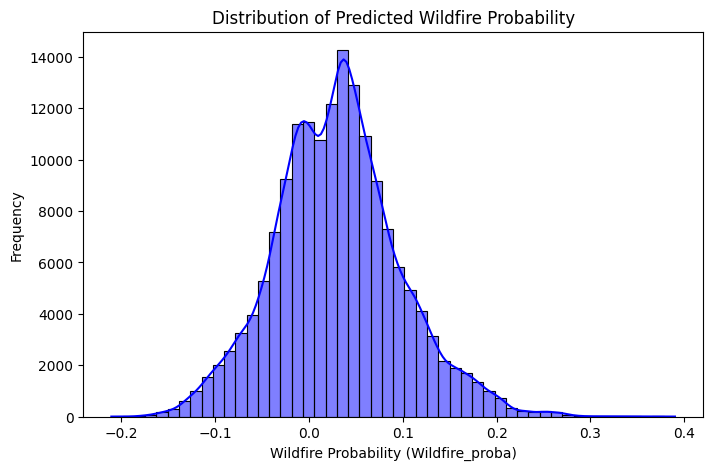

In [85]:
# Define the predictions file name
file_name = "wildfire_predictions_dnn.csv"

try:
    # Load the dataset containing predicted wildfire probability
    pr1 = pd.read_csv(file_name)

    # Check if the target feature exists in the file
    if "Wildfire_proba" not in pr1.columns:
        print(f"Error: The target feature 'Wildfire_proba' is not found in {file_name}.")
    else:
        # Plot distribution using seaborn
        plt.figure(figsize=(8, 5))
        sns.histplot(pr1["Wildfire_proba"], bins=50, kde=True, color='blue')

        # Labels and title
        plt.xlabel("Wildfire Probability (Wildfire_proba)")
        plt.ylabel("Frequency")
        plt.title("Distribution of Predicted Wildfire Probability")

        # Show plot
        plt.show()

except FileNotFoundError:
    print(f"Error: File '{file_name}' not found. Please run the prediction script first.")


# BiRNN hyperparameter optimization (Grid Search with spatial 10-fold cv)

In [88]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Bidirectional, SimpleRNN
from tensorflow.keras.optimizers import Adam

# ✅ Best Hyperparameters (from tuning)
hidden_layers = 4
neurons = 128
dropout_rate = 0.2
learning_rate = 0.001
batch_size = 32
epochs = 50

# Load preprocessed unseen dataset
X_unseen = pd.read_csv('unseen_data_preprocessed_selected.csv')

# Define predictive features (used in training)
predictive_features = [
    'Climatic water deficit', 'Elevation', 'Humidity',
    'NDVI', 'Evaptranspiration', 'Precipitation', 'Soil moisture',
    'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed',
    'LULC_Crop_land'
]

# Define metadata features (to keep for output)
metadata_features = ['point_id', 'lat_dd', 'long_dd', 'dist_fores', 'human_foot', 'tree_speci', 'pdsi']

# Separate metadata
X_metadata = X_unseen[metadata_features]

# Use only predictive features for the ML model
X_unseen_final_selected = X_unseen[predictive_features]

# Reshape input for BiRNN (samples, timesteps=1, features)
X_unseen_final_selected = X_unseen_final_selected.values.reshape((X_unseen_final_selected.shape[0], 1, X_unseen_final_selected.shape[1]))

# Build final BiRNN model using the specified hyperparameters
final_model = Sequential()
final_model.add(Bidirectional(SimpleRNN(neurons, activation='relu', return_sequences=True, input_shape=(1, X_unseen_final_selected.shape[2]))))
final_model.add(Dropout(dropout_rate))

for _ in range(hidden_layers - 2):  # Additional BiRNN layers
    final_model.add(Bidirectional(SimpleRNN(neurons // 2, activation='relu', return_sequences=True)))
    final_model.add(Dropout(dropout_rate))

final_model.add(Bidirectional(SimpleRNN(neurons // 4, activation='relu', return_sequences=False)))  # Last BiRNN layer
final_model.add(Dense(1, activation='linear'))  # Regression output

# Compile final model
final_model.compile(optimizer=Adam(learning_rate=learning_rate),
                    loss='mse', metrics=['mae'])

# Make predictions using the BiRNN model
y_pred_unseen = final_model.predict(X_unseen_final_selected)

# Add predictions to the metadata DataFrame
X_metadata['Wildfire_proba'] = np.round(y_pred_unseen, 4)

# Save the final selected results
X_metadata.to_csv('wildfire_predictions_birnn_selected_columns.csv', index=False)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5172/5172 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step


<ipython-input-88-275a8065e84c>:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_metadata['Wildfire_proba'] = np.round(y_pred_unseen, 4)


In [106]:
pr2 = pd.read_csv('wildfire_predictions_birnn_selected_columns.csv')
pr2

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Wildfire_proba
0,12493,48.383883,-123.961333,0.000000,18.0,0.0,-1.644420,0.4837
1,12494,48.383883,-123.878000,0.000000,18.0,0.0,-1.360750,0.4167
2,12495,48.383883,-123.794667,0.000000,18.0,0.0,-1.257080,0.4116
3,12497,48.383883,-123.628000,0.000000,18.0,30.0,-0.977667,0.4552
4,12498,48.383883,-123.544667,0.000000,41.0,0.0,-0.797250,0.2698
...,...,...,...,...,...,...,...,...
165493,209495,71.967217,-94.878000,551.724976,0.0,0.0,0.728250,0.2684
165494,209496,71.967217,-94.794667,551.724976,0.0,0.0,0.728250,0.2626
165495,209497,71.967217,-94.711333,555.090027,0.0,0.0,0.728250,0.2699
165496,209498,71.967217,-94.628000,555.090027,0.0,0.0,0.728250,0.2629


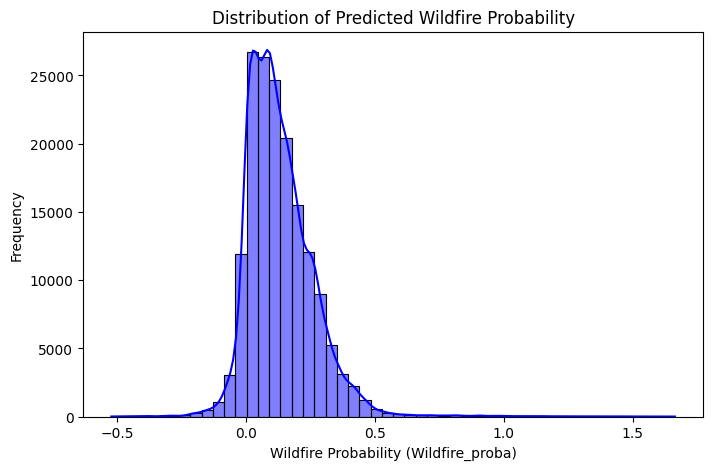

In [107]:
# Define the predictions file name
file_name = "wildfire_predictions_birnn_selected_columns.csv"

try:
    # Load the dataset containing predicted wildfire probability
    pr1 = pd.read_csv(file_name)

    # Check if the target feature exists in the file
    if "Wildfire_proba" not in pr1.columns:
        print(f"Error: The target feature 'Wildfire_proba' is not found in {file_name}.")
    else:
        # Plot distribution using seaborn
        plt.figure(figsize=(8, 5))
        sns.histplot(pr1["Wildfire_proba"], bins=50, kde=True, color='blue')

        # Labels and title
        plt.xlabel("Wildfire Probability (Wildfire_proba)")
        plt.ylabel("Frequency")
        plt.title("Distribution of Predicted Wildfire Probability")

        # Show plot
        plt.show()

except FileNotFoundError:
    print(f"Error: File '{file_name}' not found. Please run the prediction script first.")


# RNN hyperparameter optimization (Grid Search with spatial 10-fold cv)

In [90]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN
from tensorflow.keras.optimizers import Adam

# ✅ Best Hyperparameters (from tuning)
hidden_layers = 4
neurons = 64
dropout_rate = 0.1
learning_rate = 0.001
batch_size = 32
epochs = 50

# Load preprocessed unseen dataset
X_unseen = pd.read_csv('unseen_data_preprocessed_selected.csv')

# Define predictive features (used in training)
predictive_features = [
    'Climatic water deficit', 'Elevation', 'Humidity',
    'NDVI', 'Evaptranspiration', 'Precipitation', 'Soil moisture',
    'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed',
    'LULC_Crop_land'
]

# Define metadata features (to keep for output)
metadata_features = ['point_id', 'lat_dd', 'long_dd', 'dist_fores', 'human_foot', 'tree_speci', 'pdsi']

# Separate metadata
X_metadata = X_unseen[metadata_features]

# Use only predictive features for the ML model
X_unseen_final_selected = X_unseen[predictive_features]

# Reshape input for RNN (samples, timesteps=1, features)
X_unseen_final_selected = X_unseen_final_selected.values.reshape((X_unseen_final_selected.shape[0], 1, X_unseen_final_selected.shape[1]))

# Build final RNN model using the specified hyperparameters
final_model = Sequential()
final_model.add(SimpleRNN(neurons, activation='relu', return_sequences=True, input_shape=(1, X_unseen_final_selected.shape[2])))
final_model.add(Dropout(dropout_rate))

for _ in range(hidden_layers - 2):  # Additional RNN layers
    final_model.add(SimpleRNN(neurons // 2, activation='relu', return_sequences=True))
    final_model.add(Dropout(dropout_rate))

final_model.add(SimpleRNN(neurons // 4, activation='relu', return_sequences=False))  # Last RNN layer
final_model.add(Dense(1, activation='linear'))  # Regression output

# Compile final model
final_model.compile(optimizer=Adam(learning_rate=learning_rate),
                    loss='mse', metrics=['mae'])

# Make predictions using the RNN model
y_pred_unseen = final_model.predict(X_unseen_final_selected)

# Add predictions to the metadata DataFrame
X_metadata['Wildfire_proba'] = np.round(y_pred_unseen, 4)

# Save the final selected results
X_metadata.to_csv('wildfire_predictions_rnn.csv', index=False)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5172/5172 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step


<ipython-input-90-8778ffec9743>:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_metadata['Wildfire_proba'] = np.round(y_pred_unseen, 4)


In [91]:
pr3 = pd.read_csv('wildfire_predictions_rnn.csv')
pr3

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Wildfire_proba
0,12493,48.383883,-123.961333,0.000000,18.0,0.0,-1.644420,-0.7408
1,12494,48.383883,-123.878000,0.000000,18.0,0.0,-1.360750,-0.6061
2,12495,48.383883,-123.794667,0.000000,18.0,0.0,-1.257080,-0.5879
3,12497,48.383883,-123.628000,0.000000,18.0,30.0,-0.977667,-0.4309
4,12498,48.383883,-123.544667,0.000000,41.0,0.0,-0.797250,-0.3869
...,...,...,...,...,...,...,...,...
165493,209495,71.967217,-94.878000,551.724976,0.0,0.0,0.728250,-0.8536
165494,209496,71.967217,-94.794667,551.724976,0.0,0.0,0.728250,-0.8389
165495,209497,71.967217,-94.711333,555.090027,0.0,0.0,0.728250,-0.8578
165496,209498,71.967217,-94.628000,555.090027,0.0,0.0,0.728250,-0.8356


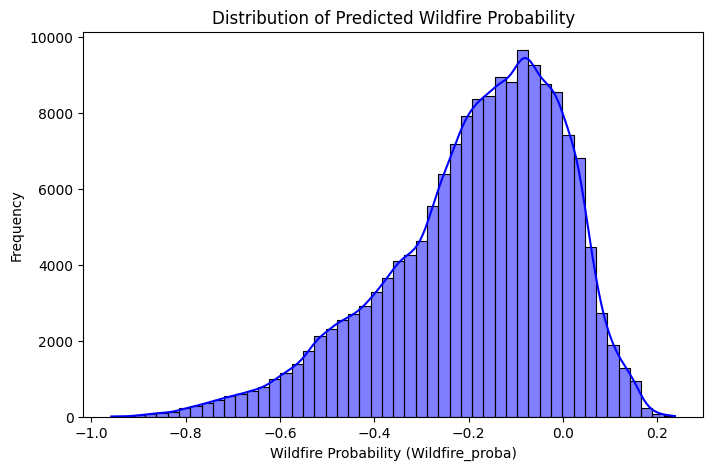

In [101]:
# Define the predictions file name
file_name = "wildfire_predictions_rnn.csv"

try:
    # Load the dataset containing predicted wildfire probability
    pr1 = pd.read_csv(file_name)

    # Check if the target feature exists in the file
    if "Wildfire_proba" not in pr1.columns:
        print(f"Error: The target feature 'Wildfire_proba' is not found in {file_name}.")
    else:
        # Plot distribution using seaborn
        plt.figure(figsize=(8, 5))
        sns.histplot(pr1["Wildfire_proba"], bins=50, kde=True, color='blue')

        # Labels and title
        plt.xlabel("Wildfire Probability (Wildfire_proba)")
        plt.ylabel("Frequency")
        plt.title("Distribution of Predicted Wildfire Probability")

        # Show plot
        plt.show()

except FileNotFoundError:
    print(f"Error: File '{file_name}' not found. Please run the prediction script first.")


# Encoder-Decoder BiRNN hyperparameter optimization (Grid Search with spatial 10-fold cv)

In [102]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, Bidirectional, RepeatVector
from tensorflow.keras.optimizers import Adam

# ✅ Best Hyperparameters (from tuning)
hidden_layers = 6
neurons = 512
dropout_rate = 0.1
learning_rate = 0.001
batch_size = 32
epochs = 50

# Load preprocessed unseen dataset
X_unseen = pd.read_csv('unseen_data_preprocessed_selected.csv')

# Define predictive features (used in training)
predictive_features = [
    'Climatic water deficit', 'Elevation', 'Humidity',
    'NDVI', 'Evaptranspiration', 'Precipitation', 'Soil moisture',
    'Shortwave radiation flux', 'Maximum Temperature', 'Wind speed',
    'LULC_Crop_land'
]

# Define metadata features (to keep for output)
metadata_features = ['point_id', 'lat_dd', 'long_dd', 'dist_fores', 'human_foot', 'tree_speci', 'pdsi']

# Separate metadata
X_metadata = X_unseen[metadata_features]

# Use only predictive features for the ML model
X_unseen_final_selected = X_unseen[predictive_features]

# Reshape input for Encoder-Decoder BiRNN (samples, timesteps=1, features)
X_unseen_final_selected = X_unseen_final_selected.values.reshape((X_unseen_final_selected.shape[0], 1, X_unseen_final_selected.shape[1]))

# Build final Encoder-Decoder BiRNN model using the specified hyperparameters
final_model = Sequential()

# Encoder
final_model.add(Bidirectional(SimpleRNN(neurons, activation='relu', return_sequences=True, input_shape=(1, X_unseen_final_selected.shape[2]))))
final_model.add(Dropout(dropout_rate))

for _ in range(hidden_layers - 2):  # Additional BiRNN layers in the encoder
    final_model.add(Bidirectional(SimpleRNN(neurons // 2, activation='relu', return_sequences=True)))
    final_model.add(Dropout(dropout_rate))

# Last RNN Layer in Encoder - Use return_sequences=False
final_model.add(Bidirectional(SimpleRNN(neurons // 4, activation='relu', return_sequences=False)))
final_model.add(Dropout(dropout_rate))

# Flatten output to 2D before RepeatVector
final_model.add(Dense(neurons // 4, activation="relu"))

# Repeat vector for decoder (Fixing dimension mismatch)
final_model.add(RepeatVector(1))

# Decoder
for _ in range(hidden_layers - 2):
    final_model.add(Bidirectional(SimpleRNN(neurons // 2, activation='relu', return_sequences=True)))
    final_model.add(Dropout(dropout_rate))

# Last RNN layer in Decoder
final_model.add(Bidirectional(SimpleRNN(neurons // 4, activation='relu', return_sequences=False)))

# Output layer
final_model.add(Dense(1, activation='linear'))  # Regression output

# Compile final model
final_model.compile(optimizer=Adam(learning_rate=learning_rate),
                    loss='mse', metrics=['mae'])

# Make predictions using the Encoder-Decoder BiRNN model
y_pred_unseen = final_model.predict(X_unseen_final_selected)

# Add predictions to the metadata DataFrame
X_metadata['Wildfire_proba'] = np.round(y_pred_unseen, 4)

# Save the final selected results
X_metadata.to_csv('wildfire_predictions_encoder_decoder_birnn.csv', index=False)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5172/5172 ━━━━━━━━━━━━━━━━━━━━ 121s 21ms/step


<ipython-input-102-fa8420d84c6e>:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_metadata['Wildfire_proba'] = np.round(y_pred_unseen, 4)


In [103]:
pr5 = pd.read_csv('wildfire_predictions_encoder_decoder_birnn.csv')
pr5

,point_id,lat_dd,long_dd,dist_fores,human_foot,tree_speci,pdsi,Wildfire_proba
0,12493,48.383883,-123.961333,0.000000,18.0,0.0,-1.644420,-0.0183
1,12494,48.383883,-123.878000,0.000000,18.0,0.0,-1.360750,-0.0178
2,12495,48.383883,-123.794667,0.000000,18.0,0.0,-1.257080,-0.0150
3,12497,48.383883,-123.628000,0.000000,18.0,30.0,-0.977667,-0.0128
4,12498,48.383883,-123.544667,0.000000,41.0,0.0,-0.797250,-0.0126
...,...,...,...,...,...,...,...,...
165493,209495,71.967217,-94.878000,551.724976,0.0,0.0,0.728250,-0.0101
165494,209496,71.967217,-94.794667,551.724976,0.0,0.0,0.728250,-0.0107
165495,209497,71.967217,-94.711333,555.090027,0.0,0.0,0.728250,-0.0103
165496,209498,71.967217,-94.628000,555.090027,0.0,0.0,0.728250,-0.0104


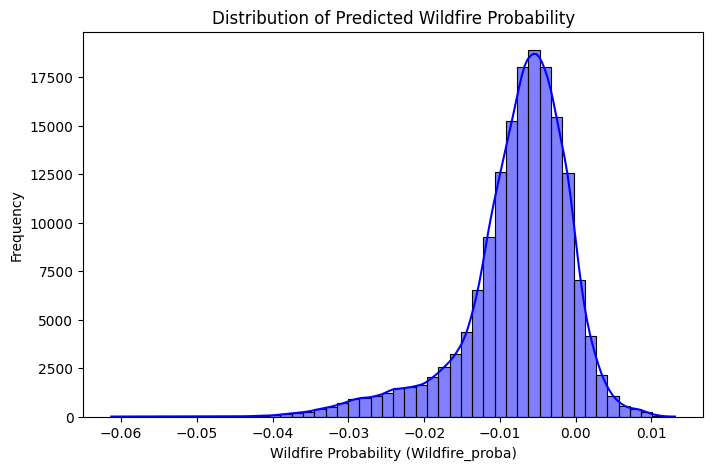

In [104]:
# Define the predictions file name
file_name = "wildfire_predictions_encoder_decoder_birnn.csv"

try:
    # Load the dataset containing predicted wildfire probability
    pr1 = pd.read_csv(file_name)

    # Check if the target feature exists in the file
    if "Wildfire_proba" not in pr1.columns:
        print(f"Error: The target feature 'Wildfire_proba' is not found in {file_name}.")
    else:
        # Plot distribution using seaborn
        plt.figure(figsize=(8, 5))
        sns.histplot(pr1["Wildfire_proba"], bins=50, kde=True, color='blue')

        # Labels and title
        plt.xlabel("Wildfire Probability (Wildfire_proba)")
        plt.ylabel("Frequency")
        plt.title("Distribution of Predicted Wildfire Probability")

        # Show plot
        plt.show()

except FileNotFoundError:
    print(f"Error: File '{file_name}' not found. Please run the prediction script first.")
